In [60]:
import pandas as pd
import os

# Construir ruta relativa
ruta = os.path.join('..', 'Data', 'TouristAccommodationClean19012026.csv')

# Leer CSV con encoding correcto
df = pd.read_csv(ruta, encoding='utf-8-sig')

# Ver primeras filas
df.head()

,apartment_id,name,description,host_id,neighbourhood_name,neighbourhood_district,room_type,accommodates,bathrooms,bedrooms,...,review_scores_communication,review_scores_location,review_scores_value,is_instant_bookable,reviews_per_month,country,city,insert_date,high_quality_stay,month
0,11964,A ROOM WITH A VIEW,Private bedroom in our attic apartment. Right ...,45553,Centro,NaN,Private room,2,2.0,1.0,...,100.0,100.0,100.0,FALSO,75.0,spain,malaga,2018-07-31,True,2018-07
1,21853,Bright and airy room,We have a quiet and sunny room with a good vie...,83531,C�rmenes,Latina,Private room,1,1.0,1.0,...,100.0,80.0,90.0,FALSO,52.0,spain,madrid,2020-01-10,True,2020-01
2,32347,Explore Cultural Sights from a Family-Friendly...,Open French doors and step onto a plant-filled...,139939,San Vicente,Casco Antiguo,Entire home/apt,4,1.0,2.0,...,100.0,100.0,100.0,VERDADERO,142.0,spain,sevilla,2019-07-29,True,2019-07
3,35379,Double 02 CasanovaRooms Barcelona,Room at a my apartment. Kitchen and 2 bathroom...,152232,l'Antiga Esquerra de l'Eixample,Eixample,Private room,2,2.0,1.0,...,100.0,100.0,90.0,VERDADERO,306.0,spain,barcelona,2020-01-10,True,2020-01
4,35801,Can Torras Farmhouse Studio Suite,Lay in bed & watch sunlight change the mood of...,153805,Quart,NaN,Private room,5,1.0,2.0,...,100.0,100.0,100.0,FALSO,39.0,spain,girona,2019-02-19,True,2019-02


**Puntuación media
AVG(review_scores_rating)**


In [61]:
import pandas as pd
import matplotlib.pyplot as plt
import numpy as np

In [62]:
#cálculo score_rating
df["review_scores_rating"] = df["review_scores_rating"]/10 
avg_rating = df["review_scores_rating"].mean()
print(f"Promedio de review_scores_rating: {avg_rating:.2f}")


Promedio de review_scores_rating: 92.02


**Promedio score rating por ciudad**

In [63]:
avg_rating_city = df.groupby("city")["review_scores_rating"].mean()
avg_rating_city.round(2)


city
barcelona    90.69
girona       91.14
madrid       92.77
malaga       92.18
mallorca     93.47
menorca      93.58
sevilla      93.84
valencia     92.29
Name: review_scores_rating, dtype: float64

**Porcentaje de alojamientos con rating > 80
COUNT(rating > 80) X  100
COUNT(TOTAL)**


In [64]:
porcentaje_altos = (df["review_scores_rating"] > 80).sum() / len(df) * 100
print(f"Porcentaje de alojamientos con rating > 80: {porcentaje_altos:.2f}%")


Porcentaje de alojamientos con rating > 80: 72.62%


**Porcentaje alojamiento por ciudad que tienen puntuación mayor a 80**

In [72]:
# Porcentaje de alojamientos con rating > 80 por ciudad
porcentaje_altos_ciudad = (
    df.groupby("city")["review_scores_rating"]
      .apply(lambda x: (x > 80).sum() / len(x) * 100)
).round(2)

resumen_ciudades = pd.DataFrame({
    "Puntuación media": avg_rating_city,
    "% alojamientos > 80": porcentaje_altos_ciudad
}).round(2)

print("\nResumen por ciudad:")
resumen_ciudades



Resumen por ciudad:


,Puntuación media,% alojamientos > 80
city,,
barcelona,90.69,72.40
girona,91.14,58.22
madrid,92.77,79.32
malaga,92.18,83.43
mallorca,93.47,65.47
menorca,93.58,78.72
sevilla,93.84,89.75
valencia,92.29,86.64


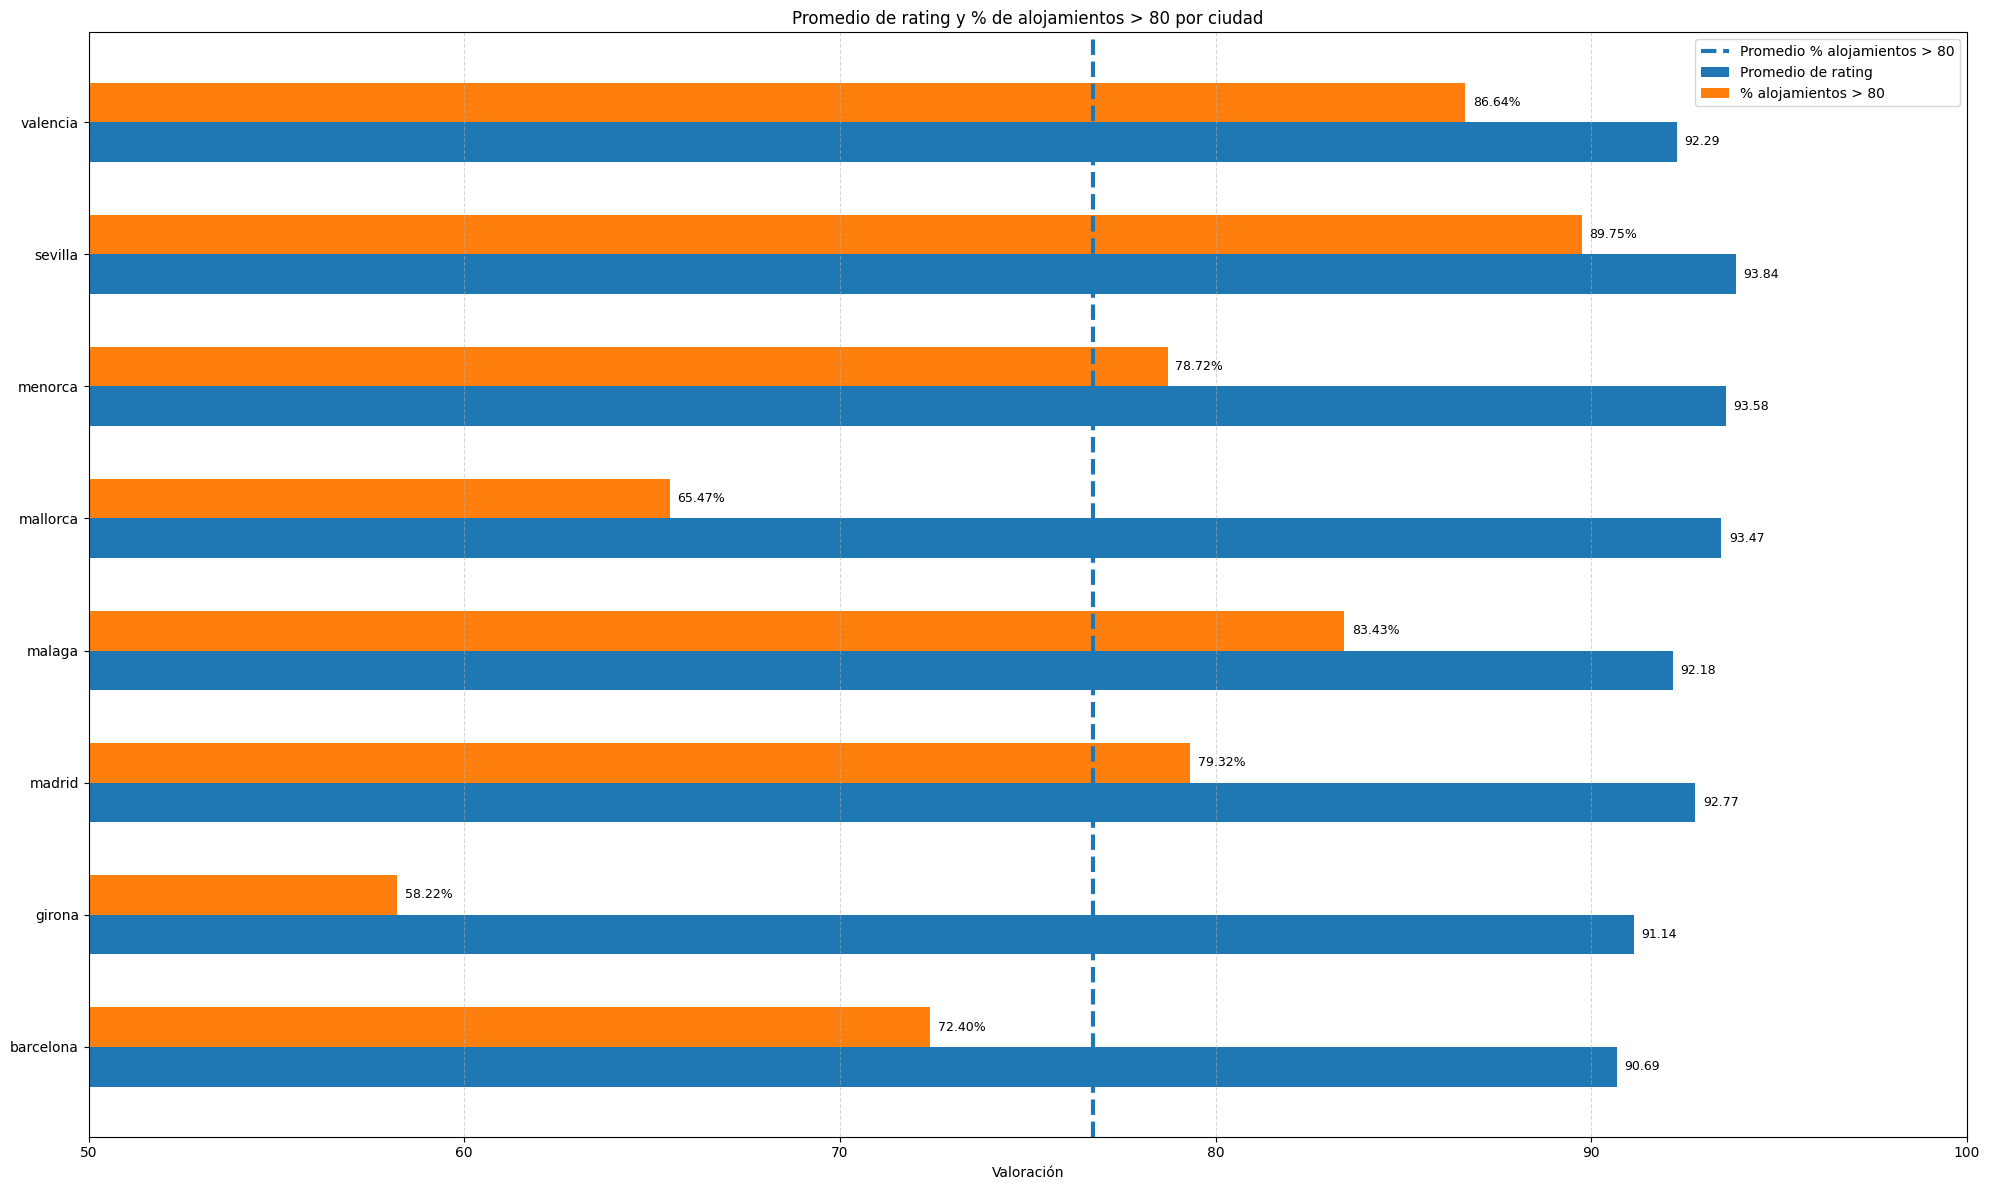

In [67]:
ciudades = avg_rating_city.index
promedios = avg_rating_city.values
porcentajes = porcentaje_altos_ciudad.loc[ciudades].values

y_pos = np.arange(len(ciudades))

#  Promedio global del porcentaje (>80)
media_porcentaje = porcentaje_altos_ciudad.mean()

plt.figure(figsize=(20, 12))

plt.barh(
    y_pos - 0.15,
    promedios,
    height=0.3,
    label='Promedio de rating'
)

plt.barh(
    y_pos + 0.15,
    porcentajes,
    height=0.3,
    label='% alojamientos > 80'
)

# Línea vertical: promedio global del %
plt.axvline(
    x=media_porcentaje,
    linestyle='--',
    linewidth=3,
    label='Promedio % alojamientos > 80'
)

for i in range(len(ciudades)):
    plt.text(promedios[i] + 0.2, i - 0.15, f'{promedios[i]:.2f}', va='center', fontsize=9)
    plt.text(porcentajes[i] + 0.2, i + 0.15, f'{porcentajes[i]:.2f}%', va='center', fontsize=9)

plt.yticks(y_pos, ciudades)
plt.xlabel('Valoración')
plt.title('Promedio de rating y % de alojamientos > 80 por ciudad')
plt.xlim(50, 100)
plt.legend()
plt.grid(axis='x', linestyle='--', alpha=0.5)
plt.tight_layout()
plt.show()
